
   Automated Expense Tracker
1. Add Expense
2. View All Expenses
3. View Total Spending
4. Set Monthly Budget
5. Generate Visual Report
6. Exit


Select an option (1-6):  1



----- ADD NEW EXPENSE -----


Enter amount (Rs.):  353
Enter category:  food
Enter brief description:  university lunch


Expense added successfully.

   Automated Expense Tracker
1. Add Expense
2. View All Expenses
3. View Total Spending
4. Set Monthly Budget
5. Generate Visual Report
6. Exit


Select an option (1-6):  5



Generating report...

Category Wise Spending:
category
food    353.0
Name: amount, dtype: float64
Chart saved as 'expense_report.png'


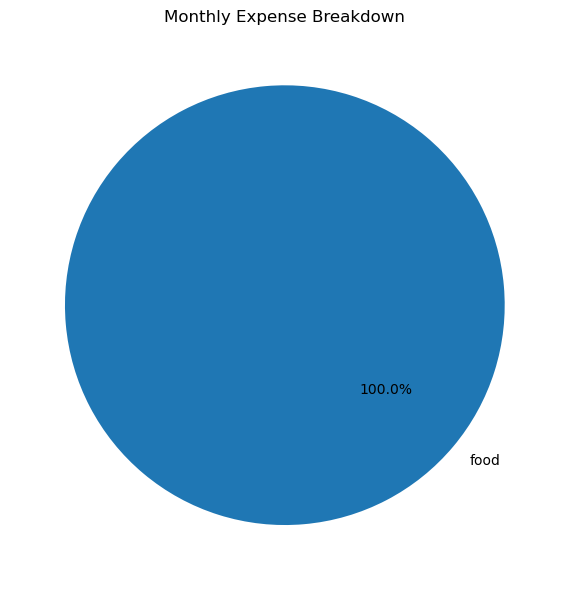


   Automated Expense Tracker
1. Add Expense
2. View All Expenses
3. View Total Spending
4. Set Monthly Budget
5. Generate Visual Report
6. Exit


Select an option (1-6):  6


Closing application...


In [15]:

import json
import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = "expenses.json"


def load_data():
    if os.path.exists(DATA_FILE):
        with open(DATA_FILE, "r") as file:
            try:
                return json.load(file)
            except json.JSONDecodeError:
                return []
    return []


def save_data(expense_list):
    with open(DATA_FILE, "w") as file:
        json.dump(expense_list, file, indent=4)


def add_expense(expense_list, monthly_budget):
    print("\n----- ADD NEW EXPENSE -----")

    try:
        amount = float(input("Enter amount (Rs.): "))

        if amount <= 0:
            print("Amount must be greater than zero.")
            return expense_list

        category = input("Enter category: ").strip()

        if category == "":
            print("Category cannot be empty.")
            return expense_list

        description = input("Enter brief description: ")

        new_expense = {
            "amount": amount,
            "category": category,
            "description": description
        }

        expense_list.append(new_expense)
        save_data(expense_list)

        print("Expense added successfully.")

        total_spent = sum(item["amount"] for item in expense_list)

        if monthly_budget > 0 and total_spent > monthly_budget:
            over_by = total_spent - monthly_budget
            print(f"Warning! Budget exceeded by Rs. {over_by:.2f}")

    except ValueError:
        print("Invalid amount entered.")

    return expense_list


def view_expenses(expense_list):
    if not expense_list:
        print("\nNo expenses recorded yet.")
        return

    print("\n----- EXPENSE LOG -----")
    print(f"{'No.':<5}{'Category':<15}{'Amount (Rs.)':<15}{'Description'}")
    print("-" * 60)

    for index, item in enumerate(expense_list, start=1):
        print(
            f"{index:<5}"
            f"{item['category']:<15}"
            f"{item['amount']:<15.2f}"
            f"{item['description']}"
        )


def generate_report(expense_list):
    if not expense_list:
        print("No data available for report.")
        return

    print("\nGenerating report...")

    df = pd.DataFrame(expense_list)

    category_totals = df.groupby("category")["amount"].sum()

    print("\nCategory Wise Spending:")
    print(category_totals)

    plt.figure(figsize=(8, 6))

    category_totals.plot(
        kind="pie",
        autopct="%1.1f%%",
        startangle=140
    )

    plt.title("Monthly Expense Breakdown")
    plt.ylabel("")
    plt.tight_layout()

    plt.savefig("expense_report.png")

    print("Chart saved as 'expense_report.png'")
    plt.show()


def main():
    expense_list = load_data()
    monthly_budget = 0.0

    while True:
        print("\n==============================")
        print("   Automated Expense Tracker")
        print("==============================")
        print("1. Add Expense")
        print("2. View All Expenses")
        print("3. View Total Spending")
        print("4. Set Monthly Budget")
        print("5. Generate Visual Report")
        print("6. Exit")

        choice = input("Select an option (1-6): ").strip()

        if choice == "1":
            expense_list = add_expense(expense_list, monthly_budget)

        elif choice == "2":
            view_expenses(expense_list)

        elif choice == "3":
            total = sum(item["amount"] for item in expense_list)
            print(f"\nTotal Spending: Rs. {total:.2f}")

        elif choice == "4":
            try:
                monthly_budget = float(
                    input("Enter monthly budget (Rs.): ")
                )
                print(
                    f"Monthly budget set to Rs. {monthly_budget:.2f}"
                )
            except ValueError:
                print("Please enter a valid number.")

        elif choice == "5":
            generate_report(expense_list)

        elif choice == "6":
            print("Closing application...")
            break

        else:
            print("Invalid option. Please try again.")


if __name__ == "__main__":
    main()


In [16]:
import os
print(os.getcwd())

C:\Users\shayan
